In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt





In [2]:
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Price'] = data.target

In [3]:
from sklearn.model_selection import train_test_split

In [4]:

X = df.drop('Price', axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=0
)

In [5]:
from sklearn.metrics import mean_squared_error,mean_absolute_error


In [6]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
ypred_lr = lr.predict(X_test)

In [8]:
lr_mse = mean_squared_error(y_test, ypred_lr)
lr_mae = mean_absolute_error(y_test, ypred_lr)

In [9]:
lr_mse

0.5289841670367201

In [10]:
lr_mae

0.5351261336554486

In [11]:
import pickle

with open ('linear_model.pkl', 'wb') as file:
    pickle.dump(lr, file)

In [12]:
import pickle
with open ('linear_model.pkl', 'rb') as file:
    lr = pickle.load(file)

In [13]:
import pandas as pd

test_df = pd.DataFrame([{
    'MedInc': 5.0,
    'HouseAge': 10,
    'AveRooms': 5,
    'AveBedrms': 1,
    'Population': 300,
    'AveOccup': 3,
    'Latitude': 34.0,
    'Longitude': -118.0
}])



In [14]:
prediction = lr.predict(test_df)
print(prediction)


[2.38684037]


In [15]:
test_df1 = pd.DataFrame([{
    'MedInc': 2.5,
    'HouseAge': 30,
    'AveRooms': 4,
    'AveBedrms': 1,
    'Population': 1000,
    'AveOccup': 2,
    'Latitude': 35.5,
    'Longitude': -120.5
}])



In [16]:
prediction = lr.predict(test_df1)
print(prediction)

[2.04070801]


In [17]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)

y_pred_poly = model_poly.predict(X_test_poly)

print("\nPolynomial Regression:")
print("MSE:", mean_squared_error(y_test, y_pred_poly))
print("MAE:", mean_absolute_error(y_test, y_pred_poly))


Polynomial Regression:
MSE: 2.7638461210581267
MAE: 0.488040645349346


In [18]:
import pickle

with open ('Polynomial_model.pkl', 'wb') as file:
    pickle.dump(model_poly, file)

In [30]:
import pickle
with open ('Polynomial_model.pkl', 'rb') as file:
    pl = pickle.load(file)

In [29]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

print("\nRidge Regression:")
print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("MAE:", mean_absolute_error(y_test, y_pred_ridge))


Ridge Regression:
MSE: 0.5290047234157982
MAE: 0.535139074528904


In [21]:
import pickle

with open ('Ridge_model.pkl', 'wb') as file:
    pickle.dump(model_poly, file)

In [22]:
import pickle
with open ('Ridge_model.pkl', 'rb') as file:
    rd = pickle.load(file)

In [23]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

print("\nLasso Regression:")
print("MSE:", mean_squared_error(y_test, y_pred_lasso))


Lasso Regression:
MSE: 0.6196149319559706


In [24]:
import pickle

with open ('Lasso_model.pkl', 'wb') as file:
    pickle.dump(lasso, file)

In [25]:
import pickle
with open ('Lasso_model.pkl', 'rb') as file:
    las = pickle.load(file)

In [26]:
results = pd.DataFrame({
    "Model": ["Linear", "Polynomial", "Ridge", "Lasso"],
    "MSE": [
        mean_squared_error(y_test, ypred_lr),
        mean_squared_error(y_test, y_pred_poly),
        mean_squared_error(y_test, y_pred_ridge),
        mean_squared_error(y_test, y_pred_lasso)
    ],
    "MAE": [
        mean_absolute_error(y_test, ypred_lr),
        mean_absolute_error(y_test, y_pred_poly),
        mean_absolute_error(y_test, y_pred_ridge),
        mean_absolute_error(y_test, y_pred_lasso)
    ]
})

print(results)

        Model       MSE       MAE
0      Linear  0.528984  0.535126
1  Polynomial  2.763846  0.488041
2       Ridge  0.529005  0.535139
3       Lasso  0.619615  0.587164


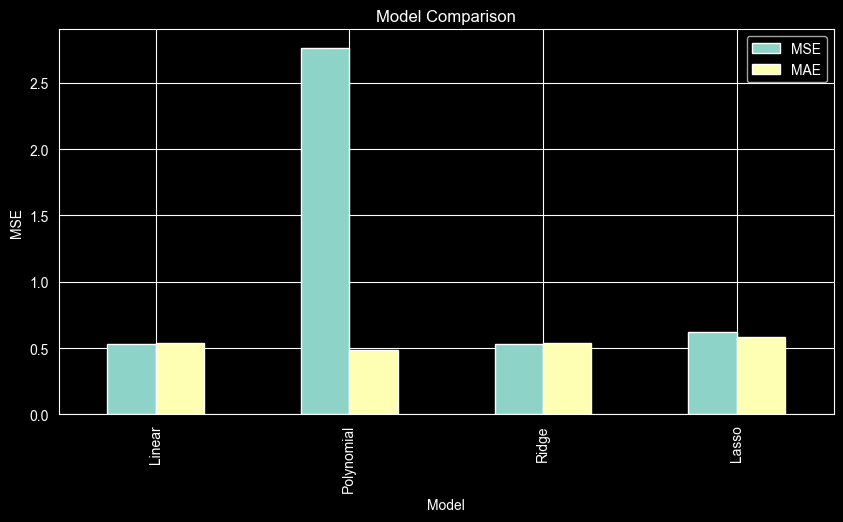

In [27]:
results.set_index("Model").plot(kind = 'bar' , figsize = (10,5))
plt.title( "Model Comparison")
plt.xlabel( "Model" )
plt.ylabel( "MSE" )
plt.show()